In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
states = ['S1', 'S2', 'S3', 'S4']   # /h/, /e/, /l/, /o/
observations = ['O1', 'O2', 'O3', 'O4']
obs_seq = [0, 1, 2, 3]  # O1 → O2 → O3 → O4

n_states = len(states)
T = len(obs_seq)


In [ ]:
print("States:", states)
print("Observations:", observations)
print("Observation Sequence:", obs_seq)


States: ['S1', 'S2', 'S3', 'S4']
Observations: ['O1', 'O2', 'O3', 'O4']
Observation Sequence: [0, 1, 2, 3]


In [ ]:
pi = np.array([1.0, 0.0, 0.0, 0.0])


In [ ]:
A = np.array([
    [0.0, 0.7, 0.3, 0.0],
    [0.0, 0.2, 0.6, 0.2],
    [0.0, 0.0, 0.3, 0.7],
    [0.0, 0.0, 0.1, 0.9]
])


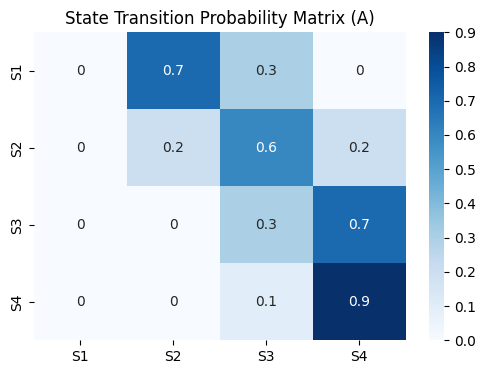

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(A, annot=True, cmap='Blues', xticklabels=states, yticklabels=states)
plt.title("State Transition Probability Matrix (A)")
plt.show()


In [ ]:
B = np.array([
    [0.6, 0.2, 0.1, 0.1],
    [0.1, 0.7, 0.1, 0.1],
    [0.1, 0.1, 0.6, 0.2],
    [0.2, 0.1, 0.2, 0.5]
])


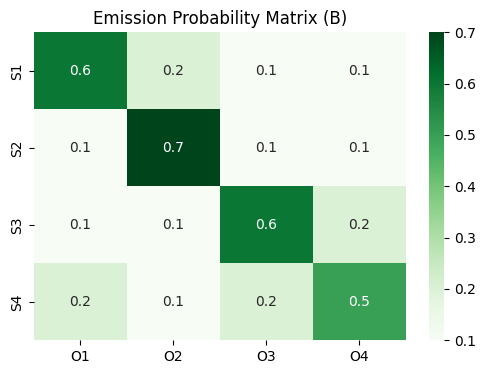

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(B, annot=True, cmap='Greens', xticklabels=observations, yticklabels=states)
plt.title("Emission Probability Matrix (B)")
plt.show()


In [ ]:
delta = np.zeros((n_states, T))
psi = np.zeros((n_states, T), dtype=int)

# Initialization step
delta[:, 0] = pi * B[:, obs_seq[0]]

print("Delta after initialization:\n", delta)


Delta after initialization:
 [[0.6 0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]


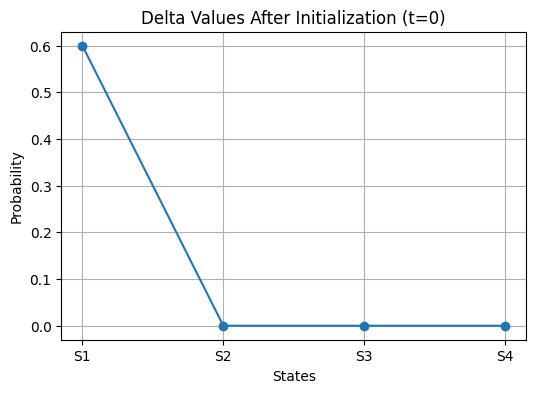

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(states, delta[:, 0], marker='o')
plt.title("Delta Values After Initialization (t=0)")
plt.xlabel("States")
plt.ylabel("Probability")
plt.grid(True)
plt.show()


In [ ]:
for t in range(1, T):
    for j in range(n_states):
        prob = delta[:, t-1] * A[:, j]
        psi[j, t] = np.argmax(prob)
        delta[j, t] = np.max(prob) * B[j, obs_seq[t]]

print("Delta Table Through Time:\n", delta)
print("Psi Table (Backpointers):\n", psi)


Delta Table Through Time:
 [[6.0000e-01 0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 2.9400e-01 5.8800e-03 1.1760e-04]
 [0.0000e+00 1.8000e-02 1.0584e-01 6.3504e-03]
 [0.0000e+00 0.0000e+00 1.1760e-02 3.7044e-02]]
Psi Table (Backpointers):
 [[0 0 0 0]
 [0 0 1 1]
 [0 0 1 2]
 [0 0 1 2]]


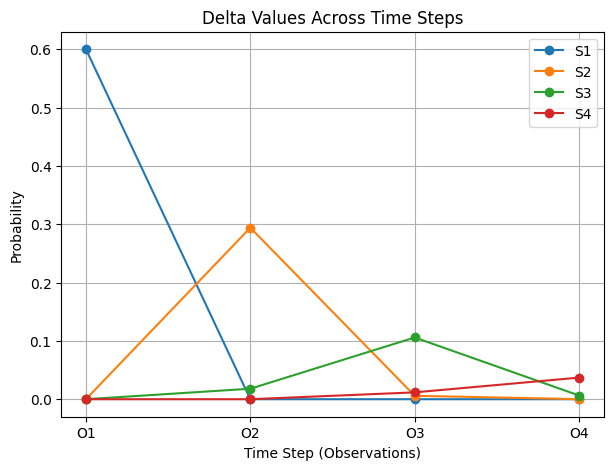

In [ ]:
plt.figure(figsize=(7, 5))
for s in range(n_states):
    plt.plot(range(T), delta[s, :], marker='o', label=states[s])

plt.xticks(range(T), observations)
plt.title("Delta Values Across Time Steps")
plt.xlabel("Time Step (Observations)")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
states_seq = np.zeros(T, dtype=int)
states_seq[-1] = np.argmax(delta[:, -1])

for t in range(T - 2, -1, -1):
    states_seq[t] = psi[states_seq[t + 1], t + 1]

most_likely_states = [states[s] for s in states_seq]
print("Most Likely State Path:", most_likely_states)


Most Likely State Path: ['S1', 'S2', 'S3', 'S4']


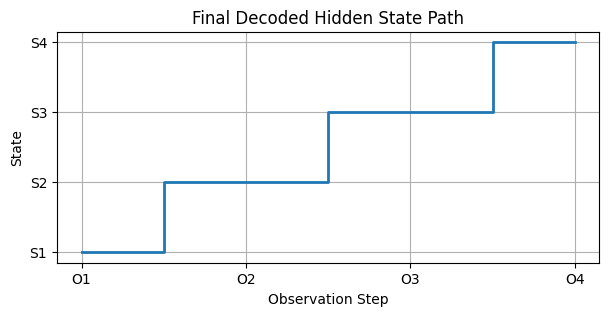

In [ ]:
plt.figure(figsize=(7, 3))
plt.step(range(T), states_seq, where='mid', linewidth=2)
plt.yticks(range(n_states), states)
plt.xticks(range(T), observations)
plt.title("Final Decoded Hidden State Path")
plt.xlabel("Observation Step")
plt.ylabel("State")
plt.grid(True)
plt.show()


In [ ]:
probability = np.max(delta[:, -1])
print("Probability of the Most Likely State Sequence:", probability)


Probability of the Most Likely State Sequence: 0.03704399999999999


In [ ]:
phoneme_map = {'S1':'/h/', 'S2':'/e/', 'S3':'/l/', 'S4':'/o/'}

decoded_phonemes = [phoneme_map[s] for s in most_likely_states]

print("Decoded Phoneme Sequence:", decoded_phonemes)


Decoded Phoneme Sequence: ['/h/', '/e/', '/l/', '/o/']
